<a href="https://colab.research.google.com/github/tejinderpa/Machine-Learning/blob/feature%2Fweb-scraping/AgglomerativeHierarchicalClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("countries of the world.csv", decimal=',')  # uses comma for decimals
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [4]:
df.shape

(227, 20)

In [3]:
df.isnull().sum()

,0
Country,0
Region,0
Population,0
Area (sq. mi.),0
Pop. Density (per sq. mi.),0
Coastline (coast/area ratio),0
Net migration,3
Infant mortality (per 1000 births),3
GDP ($ per capita),1
Literacy (%),18


In [5]:
df.columns = df.columns.str.strip()

In [6]:
df = df.drop(columns=['Climate', 'Literacy (%)'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Phones (per 1000)                   223 non-null    float64
 10  Arable (%)                          225 non-null    float64
 11  Crops (%)                           225 non-n

In [8]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [9]:
print(df.isnull().sum().sort_values(ascending=False))

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Birthrate                             0
Deathrate                             0
Agriculture                           0
Industry                              0
Service                               0
dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

# Drop non-numeric columns
features = df.drop(columns=["Country", "Region"])

# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [11]:
countries = df["Country"].values
regions = df["Region"].values

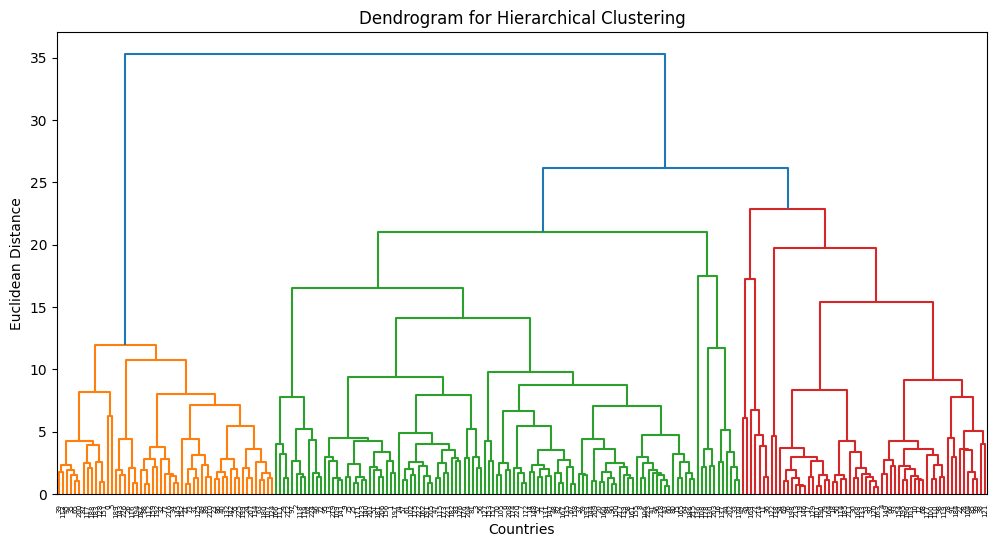

In [12]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")
plt.show()


In [14]:
from sklearn.cluster import AgglomerativeClustering

# Fit model
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels = hc.fit_predict(scaled_data)

# Attach cluster labels to your original dataframe
df['Cluster'] = labels


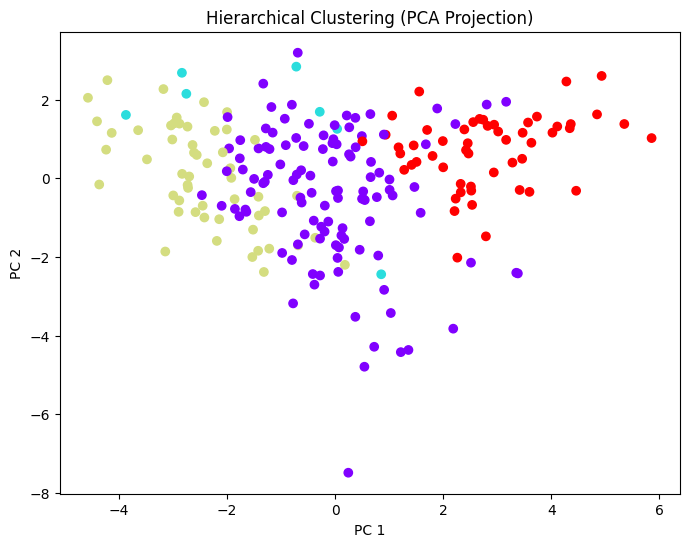

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='rainbow')
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


In [16]:
# View average values for each cluster
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)


           Population  Area (sq. mi.)  Pop. Density (per sq. mi.)  \
Cluster                                                             
0        1.521476e+07    3.070036e+05                  181.896491   
1        4.417292e+08    9.396379e+06                   76.785714   
2        1.473526e+07    1.206912e+05                 1162.216981   
3        1.729224e+07    5.401475e+05                   59.858491   

         Coastline (coast/area ratio)  Net migration  \
Cluster                                                
0                           29.284825      -1.434649   
1                            0.462857       1.981429   
2                           25.978868       2.775849   
3                            1.621509       0.209434   

         Infant mortality (per 1000 births)  GDP ($ per capita)  \
Cluster                                                           
0                                 26.545789         6788.157895   
1                                 20.201429    

In [17]:
for i in range(df["Cluster"].nunique()):
    print(f"\nCluster {i} Sample Countries:")
    print(df[df["Cluster"] == i]["Country"].head(5).to_string(index=False))



Cluster 0 Sample Countries:
          Albania 
          Algeria 
   American Samoa 
         Anguilla 
Antigua & Barbuda 

Cluster 1 Sample Countries:
Australia 
   Brazil 
   Canada 
    China 
    India 

Cluster 2 Sample Countries:
 Andorra 
   Aruba 
 Austria 
Barbados 
 Belarus 

Cluster 3 Sample Countries:
Afghanistan 
     Angola 
      Benin 
     Bhutan 
    Bolivia 
